<a href="https://colab.research.google.com/github/Nandhinimh/DEEPFAKE_DETECTION_USING_CNN/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
import zipfile, os
uploaded = files.upload()

Saving archive.zip to archive.zip


In [3]:
# Extract uploaded file
for fn in uploaded.keys():
    zip_name = fn

dataset_dir = "/content/deepfake_dataset"
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(dataset_dir)

print("Dataset extracted successfully at:", dataset_dir)
print("Folders:", os.listdir(dataset_dir))

Dataset extracted successfully at: /content/deepfake_dataset
Folders: ['real_and_fake_face', 'real_and_fake_face_detection']


In [4]:
# Import Libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [10]:
#Feature Extraction (Color Histogram)
def extract_features(img_path, bins=(8,8,8)):
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.resize(img, (128,128))
    hist = cv2.calcHist([img], [0,1,2], None, bins, [0,256,0,256,0,256])
    hist = cv2.normalize(hist, hist).flatten()
    return hist

X, y = [], []
# Corrected classes to match the actual subdirectories containing images
classes = ['real_and_fake_face/training_real', 'real_and_fake_face/training_fake']

for label, cls in enumerate(classes):
    folder = os.path.join(dataset_dir, cls)
    # Check if the folder exists and is a directory
    if os.path.isdir(folder):
        for file in os.listdir(folder):
            path = os.path.join(folder, file)
            # Check if the path is a file
            if os.path.isfile(path):
                feat = extract_features(path)
                if feat is not None:
                    X.append(feat)
                    y.append(label)

X = np.array(X)
y = np.array(y)
print(f"Extracted features: {X.shape}")

Extracted features: (2041, 512)


In [12]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Data split and scaled successfully.")

Data split and scaled successfully.


In [13]:
# Train ML models
print("\nTraining models...")
svm = SVC(kernel='rbf', gamma='scale')
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

svm.fit(X_train, y_train)
rf.fit(X_train, y_train)
knn.fit(X_train, y_train)

print("Models trained successfully.")


Training models...
Models trained successfully.


In [15]:
# Evaluate models
y_pred_svm = svm.predict(X_test)
y_pred_rf  = rf.predict(X_test)
y_pred_knn = knn.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
acc_rf  = accuracy_score(y_test, y_pred_rf)
acc_knn = accuracy_score(y_test, y_pred_knn)

print("\nModel Performance Summary:")
print(f"SVM Accuracy:  {acc_svm*100:.2f}%")
print(f"RF Accuracy:   {acc_rf*100:.2f}%")
print(f"KNN Accuracy:  {acc_knn*100:.2f}%")


Model Performance Summary:
SVM Accuracy:  54.28%
RF Accuracy:   57.95%
KNN Accuracy:  50.86%


In [16]:
# Detailed report
print("\nSVM Report:\n", classification_report(y_test, y_pred_svm))
print("RF Report:\n", classification_report(y_test, y_pred_rf))
print("KNN Report:\n", classification_report(y_test, y_pred_knn))


SVM Report:
               precision    recall  f1-score   support

           0       0.55      0.85      0.66       218
           1       0.53      0.19      0.28       191

    accuracy                           0.54       409
   macro avg       0.54      0.52      0.47       409
weighted avg       0.54      0.54      0.49       409

RF Report:
               precision    recall  f1-score   support

           0       0.59      0.67      0.63       218
           1       0.56      0.48      0.51       191

    accuracy                           0.58       409
   macro avg       0.58      0.57      0.57       409
weighted avg       0.58      0.58      0.58       409

KNN Report:
               precision    recall  f1-score   support

           0       0.54      0.55      0.54       218
           1       0.47      0.46      0.47       191

    accuracy                           0.51       409
   macro avg       0.51      0.51      0.51       409
weighted avg       0.51      0.51  

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


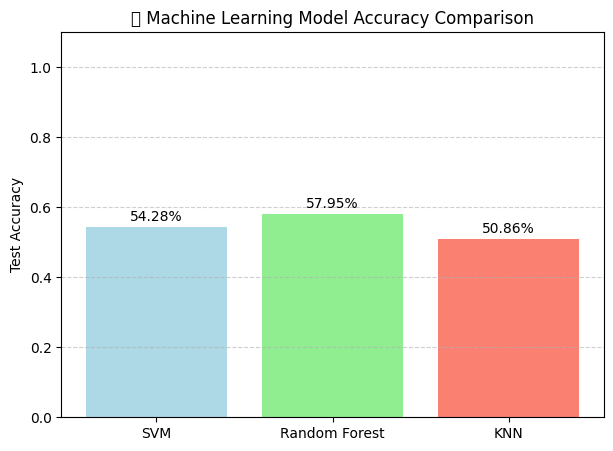

In [17]:
# Visual Comparison
models = ['SVM', 'Random Forest', 'KNN']
accuracies = [acc_svm, acc_rf, acc_knn]

plt.figure(figsize=(7,5))
bars = plt.bar(models, accuracies, color=['lightblue','lightgreen','salmon'])
plt.title("🏆 Machine Learning Model Accuracy Comparison")
plt.ylabel("Test Accuracy")

for bar, acc in zip(bars, accuracies):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{acc*100:.2f}%", ha='center', va='bottom')

plt.ylim(0,1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [19]:
#Identify best model
best_model = models[np.argmax(accuracies)]
print(f"\nBest Performing ML Model: {best_model}")



Best Performing ML Model: Random Forest
